In [ ]:
# #to fetch ic5o with header  run the bewlow  command in terminal 
# #head -n 1 ABL1_P00519_values.csv > ABL1_P00519_IC50_only.csv
# #grep "IC50" ABL1_P00519_values.csv >> ABL1_P00519_IC50_only.csv


import os
os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1/ttbk1_final')

import pandas as pd

# Load both datasets
df1 = pd.read_csv("ABL1_CHEMBL1862_IC50_chembl_Wsmile.csv")
df2 = pd.read_csv("ABL1_P00519_IC50_only.csv")

df2 = df2[["SMILES", "Affinity Value"]]
df2.columns = ["smiles", "standard_value"]  # rename for consistency

common_smiles = set(df1["smiles"]) & set(df2["smiles"])

# Filter rows with common SMILES
df1_common = df1[df1["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df1"})
df2_common = df2[df2["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df2"})

# Merge on SMILES
merged = pd.merge(df1_common, df2_common, on="smiles")

# print(merged)  # Show first 10 entries

print(f"Number of common SMILES: {len(common_smiles)}")
# print(list(common_smiles)[:10])  # Print first 10 for preview

# # Combine the two datasets
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df


# # Drop entries with missing SMILES or IC50
combined_df = combined_df.dropna(subset=["smiles", "standard_value"])
combined_df
# # Convert IC50 values to numeric
combined_df["standard_value"] = pd.to_numeric(combined_df["standard_value"], errors="coerce")
# combined_df
# # Drop any rows with NaNs in standard_value after conversion
combined_df = combined_df.dropna(subset=["standard_value"])
combined_df

# # Keep only the entry with the lowest IC50 for each SMILES
min_ic50_df = combined_df.loc[combined_df.groupby("smiles")["standard_value"].idxmin()]
min_ic50_df
# # Select only relevant columns
final_df = min_ic50_df[["smiles", "standard_value"]].reset_index(drop=True)

# # Save to a new CSV file
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)



In [3]:
final_df= pd.read_csv("dedeuplicated_combined_ic50.csv")
##check for duplication
# Ensure SMILES column is treated as string
final_df["smiles"] = final_df["smiles"].astype(str)

# Check for duplicates in the 'smiles' column
duplicates = final_df[final_df.duplicated("smiles", keep=False)]  # keep=False shows *all* duplicates

# Print number and preview of duplicates
print(f"Total duplicate SMILES entries: {len(duplicates)}")
print(duplicates.head())



Total duplicate SMILES entries: 0
Empty DataFrame
Columns: [smiles, standard_value, is_valid, label]
Index: []


In [4]:
from rdkit import Chem
import pandas as pd


# Check for invalid SMILES
def check_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None
final_df['is_valid'] = final_df['smiles'].apply(check_smiles)

# Report
invalid_smiles = final_df[~final_df['is_valid']]
print(f"Total SMILES: {len(final_df)}")
print(f"Invalid SMILES: {len(invalid_smiles)}")

if not invalid_smiles.empty:
    print("List of invalid SMILES:")
    print(invalid_smiles[['smiles']])
else:
    print("✅ All SMILES are valid.")


# remove the invalid using
final_df = final_df[final_df['is_valid']]
# final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)

Total SMILES: 124
Invalid SMILES: 0
✅ All SMILES are valid.


In [5]:
#classification actives/inactives

# 2) Convert IC50 column to numeric (in case there were strings)
final_df['standard_value'] = pd.to_numeric(final_df['standard_value'], errors='coerce')

# 3) Add classification column
final_df['label'] = (final_df['standard_value'] < 1000).astype(int)
# 1 = Active, 0 = Inactive


# 4) Quick sanity check
print(final_df[['standard_value', 'label']].head())

# 5) (Optional) Save back out
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)


   standard_value  label
0           750.0      1
1           390.0      1
2           750.0      1
3          4900.0      0
4          4700.0      0


In [6]:
# Count how many of each
counts = final_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(final_df))

Inactives (0): 49
Actives   (1): 75
124


In [ ]:
# # #SMILE AUGMENTATION FOR TTBK ( not needed anymore)
# from rdkit import Chem
# from rdkit.Chem import MolToSmiles
# import pandas as pd

# def random_smiles(smiles, n=5):
#     mol = Chem.MolFromSmiles(smiles)
#     return [MolToSmiles(mol, doRandom=True) for _ in range(n)]

# # Load your small-data TTBK DataFrame with columns: smiles, label
# ttbk_df = pd.read_csv("dedeuplicated_combined_ic50.csv")

# augmented_rows = []
# for _, row in ttbk_df.iterrows():
#     smi, lbl = row['smiles'], row['label']
#     for rnd_smi in random_smiles(smi, n=5):
#         augmented_rows.append({'smiles': rnd_smi, 'label': lbl})

# aug_df = pd.DataFrame(augmented_rows)
# # Combine with the original
# ttbk_augmented = pd.concat([ttbk_df, aug_df], ignore_index=True)
# ttbk_augmented.to_csv("trial.csv")
# ttbk_augmented



,smiles,standard_value,is_valid,label
0,Brc1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,750.0,True,0
1,C(Cn1cc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)nn1)c1cc...,390.0,True,0
2,C(Oc1ccc(Nc2ncnc3[nH]ccc23)cc1)c1ccccc1,750.0,True,0
3,C1CN(CCO1)c1ccc(Nc2ncnc3[nH]ccc23)cc1,4900.0,True,0
4,C1CN(CCO1)c1cccc(Nc2ncnc3[nH]ccc23)c1,4700.0,True,0
...,...,...,...,...
739,c1(ccc(cc1)N1CCOCC1)Nc1ncnc2c1cc[nH]2,NaN,NaN,0
740,n1c(Nc2ccc(N3CCOCC3)cc2)c2c([nH]cc2)nc1,NaN,NaN,0
741,c1(N2CCOCC2)ccc(Nc2c3c([nH]cc3)ncn2)cc1,NaN,NaN,0
742,c12c(cc[nH]2)c(Nc2ccc(N3CCOCC3)cc2)ncn1,NaN,NaN,0


In [14]:
# Count how many of each
counts = aug_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(aug_df))

Inactives (0): 455
Actives   (1): 165
620


Running pipeline...
Loaded 744 clean entries; labels: [0, 1]
SMILES valid on sample: 100.0%
FP test: 5/5 successful
Class distribution before SMOTE: {0: 437, 1: 158}
Applying SMOTE...
Train size: 595 → 874 after SMOTE
Pipeline completed.
                                              smiles  label
0           Brc1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1      0
1  C(Cn1cc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)nn1)c1cc...      0
2            C(Oc1ccc(Nc2ncnc3[nH]ccc23)cc1)c1ccccc1      0
3              C1CN(CCO1)c1ccc(Nc2ncnc3[nH]ccc23)cc1      0
4              C1CN(CCO1)c1cccc(Nc2ncnc3[nH]ccc23)c1      0


In [ ]:
#MAIN CODE
import numpy as np
import pandas as pd
import joblib
import json
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# ──────────────────────────────────────────────────────────────────────────────
# Utility Functions
# ──────────────────────────────────────────────────────────────────────────────
def generate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol) if mol else None

def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = []
    for smi in smiles_list:
        m = Chem.MolFromSmiles(smi)
        if m:
            bit = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bit, arr)
            fps.append(arr)
    return np.array(fps)

def load_and_process(path):
    df = pd.read_csv(path).dropna(subset=['smiles', 'label'])
    df['label'] = df['label'].astype(int)
    df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)]
    df['scaffold'] = df['smiles'].apply(generate_scaffold)
    return df

# ──────────────────────────────────────────────────────────────────────────────
# Nested CV Evaluation + Save Best Estimators
# ──────────────────────────────────────────────────────────────────────────────
def nested_cv_evaluation_and_save(X, y, models, param_grids, save_prefix="model"):
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    best_params_dict = defaultdict(list)

    for model_name, model in models.items():
        print(f"\n Running Nested CV for {model_name}...")
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        grid = GridSearchCV(model, param_grids[model_name], cv=inner_cv,
                            scoring='f1_macro', n_jobs=1)

        f1_scores, roc_scores, pr_scores = [], [], []
        augmented_counts = []
        original_counts = []

        for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            original_counts.append(len(y_train))
            print(f"  Fold {fold_idx}: Samples before SMOTE = {len(y_train)}")

            sm = SMOTE(random_state=42, k_neighbors=min(5, np.bincount(y_train).min() - 1))
            X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
            augmented_counts.append(len(y_train_sm))
            print(f"  Fold {fold_idx}: Samples after SMOTE = {len(y_train_sm)}")

            grid.fit(X_train_sm, y_train_sm)
            best_model = grid.best_estimator_

            best_params_dict[model_name].append(grid.best_params_)

            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

            f1_scores.append(f1_score(y_test, y_pred))
            roc_scores.append(roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan)
            pr_scores.append(average_precision_score(y_test, y_proba) if y_proba is not None else np.nan)

        # Refit best on full dataset
        print(f"[] Refitting best {model_name} model on full dataset for saving...")
        sm = SMOTE(random_state=42, k_neighbors=min(5, np.bincount(y).min() - 1))
        X_bal, y_bal = sm.fit_resample(X, y)
        grid.fit(X_bal, y_bal)
        final_model = grid.best_estimator_

        best_params_full_data = grid.best_params_

        fname = f"{save_prefix}_{model_name.lower()}.pkl"
        joblib.dump(final_model, fname)
        print(f"Saved {model_name} model to: {fname}")

        results.append({
            "Model": model_name,
            "F1_mean": np.mean(f1_scores),
            "F1_std": np.std(f1_scores),
            "ROC_AUC_mean": np.mean(roc_scores),
            "PR_AUC_mean": np.mean(pr_scores),
            "Best_Params_Per_Fold": json.dumps(best_params_dict[model_name], indent=4),
            "Best_Params_Full_Data": json.dumps(best_params_full_data, indent=4),
            "Avg_Train_Size_Before_SMOTE": int(np.mean(original_counts)),
            "Avg_Train_Size_After_SMOTE": int(np.mean(augmented_counts))
        })

    return pd.DataFrame(results)



# ──────────────────────────────────────────────────────────────────────────────
# Main Script
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_and_process("dedeuplicated_combined_ic50.csv")
    X = smiles_to_fp(df['smiles'].values)
    y = df['label'].values
    # do a one-time split and save it
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )
    # save them to disk
    np.savez_compressed(
        "train_test_data.npz",
        X_train=X_train,
        X_test =X_test,
        y_train=y_train,
        y_test =y_test
    )
    print("Saved fixed train/test split to train_test_data.npz")


    models = {
        "CatBoost": CatBoostClassifier(task_type="GPU", devices="0", verbose=0, random_state=42),
        "SVM": Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=42))]),
        "KNN": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
        "NaiveBayes": GaussianNB(),
        "XGB": XGBClassifier(tree_method="gpu_hist", predictor="gpu_predictor",
                             use_label_encoder=False, eval_metric='logloss', random_state=42)
    }

    param_grids = {
        "CatBoost": {'depth': [4, 6], 'learning_rate': [0.01], 'iterations': [100]},
        "SVM": {'svc__C': [0.1, 1], 'svc__gamma': ['scale']},
        "KNN": {'knn__n_neighbors': [3, 5]},
        "NaiveBayes": {'var_smoothing': [1e-9, 1e-8]},
        "XGB": {'max_depth': [3, 5], 'learning_rate': [0.01], 'n_estimators': [100]}
    }

    results_df = nested_cv_evaluation_and_save(X, y, models, param_grids)
    print("\n[NESTED CV RESULTS]")
    print(results_df.to_string(index=False))


Saved fixed train/test split to train_test_data.npz

 Running Nested CV for CatBoost...
  Fold 1: Samples before SMOTE = 99
  Fold 1: Samples after SMOTE = 120
  Fold 2: Samples before SMOTE = 99
  Fold 2: Samples after SMOTE = 120
  Fold 3: Samples before SMOTE = 99
  Fold 3: Samples after SMOTE = 120
  Fold 4: Samples before SMOTE = 99
  Fold 4: Samples after SMOTE = 120
  Fold 5: Samples before SMOTE = 100
  Fold 5: Samples after SMOTE = 120
[] Refitting best CatBoost model on full dataset for saving...
Saved CatBoost model to: model_catboost.pkl

 Running Nested CV for SVM...
  Fold 1: Samples before SMOTE = 99
  Fold 1: Samples after SMOTE = 120
  Fold 2: Samples before SMOTE = 99
  Fold 2: Samples after SMOTE = 120
  Fold 3: Samples before SMOTE = 99
  Fold 3: Samples after SMOTE = 120
  Fold 4: Samples before SMOTE = 99
  Fold 4: Samples after SMOTE = 120
  Fold 5: Samples before SMOTE = 100
  Fold 5: Samples after SMOTE = 120
[] Refitting best SVM model on full dataset for savi

In [14]:
#For metrics
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score, average_precision_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.base import clone


# -------------------------
# CONFIG
# -------------------------
npz_path = "train_test_data.npz"  # your saved split
model_files = ["model_catboost.pkl","model_svm.pkl","model_knn.pkl","model_naivebayes.pkl", "model_xgb.pkl","cat_xgb_svm_voting.pkl"]  # adjust if needed
n_splits = 6
mean_fpr = np.linspace(0, 1, 200)

# -------------------------
# HELPERS
# -------------------------
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# -------------------------
# LOAD DATA (combine train+test)
# -------------------------
d = np.load(npz_path)
X = np.vstack([d["X_train"], d["X_test"]])
y = np.hstack([d["y_train"], d["y_test"]])
print(f"Loaded data: X.shape={X.shape}, y.shape={y.shape}")

# -------------------------
# CV + METRICS
# -------------------------
results_summary = []
roc_curves = {}

for mf in model_files:
    if not os.path.exists(mf):
        print(f"Skipping {mf} (not found)")
        continue

    trained_model = joblib.load(mf)  # Could be a Pipeline
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    metrics_list = []
    tprs = []
    aucs = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # SMOTE
        sm = SMOTE(random_state=42)
        X_res, y_res = sm.fit_resample(X_train, y_train)

        # Clone the original model to keep same params
        model = clone(trained_model)
        model.fit(X_res, y_res)

        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = y_pred

        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        spec = specificity_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)
        aucroc = roc_auc_score(y_test, y_proba)
        aucpr = average_precision_score(y_test, y_proba)

        metrics_list.append([prec, rec, f1, spec, mcc, aucroc, aucpr])

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        # Add points (0,0) and (1,1) if missing
        if fpr[0] != 0.0:
            fpr = np.insert(fpr, 0, 0.0)
            tpr = np.insert(tpr, 0, 0.0)
        if fpr[-1] != 1.0:
            fpr = np.append(fpr, 1.0)
            tpr = np.append(tpr, 1.0)

        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)
        aucs.append(aucroc)


    metrics_arr = np.array(metrics_list)
    means = metrics_arr.mean(axis=0)
    stds = metrics_arr.std(axis=0)

    results_summary.append([mf] + list(means) + list(stds))

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    roc_curves[mf] = (mean_tpr, std_tpr, np.mean(aucs))

# -------------------------
# RESULTS TABLE
# -------------------------
cols = ["Model", "Precision_mean", "Recall_mean", "F1_mean", "Specificity_mean",
        "MCC_mean", "AUROC_mean", "AUPRC_mean",
        "Precision_std", "Recall_std", "F1_std", "Specificity_std",
        "MCC_std", "AUROC_std", "AUPRC_std"]

df_results = pd.DataFrame(results_summary, columns=cols)
df_results
# After creating df_results
metrics_names = ["Precision", "Recall", "F1", "Specificity", "MCC", "AUROC", "AUPRC"]

formatted_data = []
for _, row in df_results.iterrows():
    formatted_row = [row["Model"]]
    for metric in metrics_names:
        mean_val = row[f"{metric}_mean"]
        std_val = row[f"{metric}_std"]
        # Format as mean = std OR mean ± std
        formatted_row.append(f"{mean_val:.3f} ± {std_val:.3f}")
    formatted_data.append(formatted_row)

# Column headers
formatted_cols = ["Model"] + metrics_names

# Create new DataFrame with formatted numbers
df_formatted = pd.DataFrame(formatted_data, columns=formatted_cols)

# Print table
print(df_formatted.to_string(index=False))

df_formatted.to_csv("nested_cv_results.csv", index=False)
print(" Saved nested CV results to nested_cv_results.csv")



Loaded data: X.shape=(124, 2048), y.shape=(124,)


/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:23] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [12:41:24] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
/home/umar/.local/lib/

                 Model     Precision        Recall            F1   Specificity           MCC         AUROC         AUPRC
    model_catboost.pkl 0.896 ± 0.117 0.879 ± 0.102 0.881 ± 0.079 0.822 ± 0.213 0.715 ± 0.197 0.918 ± 0.067 0.957 ± 0.034
         model_svm.pkl 0.876 ± 0.106 0.786 ± 0.144 0.820 ± 0.094 0.819 ± 0.150 0.615 ± 0.182 0.907 ± 0.065 0.948 ± 0.040
         model_knn.pkl 0.830 ± 0.114 0.590 ± 0.141 0.684 ± 0.117 0.815 ± 0.121 0.406 ± 0.210 0.795 ± 0.132 0.835 ± 0.090
  model_naivebayes.pkl 0.791 ± 0.076 0.842 ± 0.099 0.813 ± 0.076 0.657 ± 0.132 0.515 ± 0.192 0.768 ± 0.114 0.783 ± 0.107
         model_xgb.pkl 0.908 ± 0.068 0.892 ± 0.080 0.898 ± 0.065 0.859 ± 0.108 0.753 ± 0.148 0.904 ± 0.069 0.934 ± 0.046
cat_xgb_svm_voting.pkl 0.892 ± 0.096 0.880 ± 0.088 0.881 ± 0.064 0.819 ± 0.181 0.712 ± 0.159 0.917 ± 0.084 0.955 ± 0.045
 Saved nested CV results to nested_cv_results.csv


/home/umar/.local/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [12:41:44] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


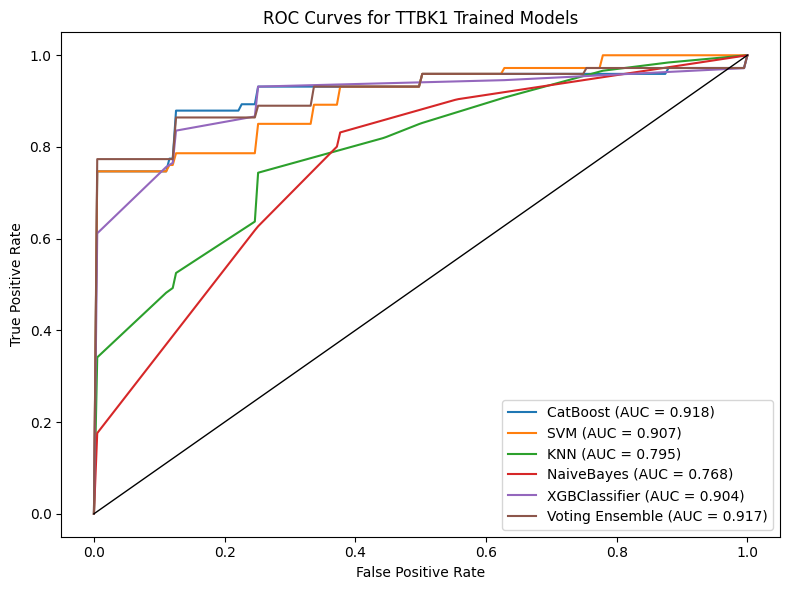

In [22]:
# Map file names to clean display names
name_map = {
    "model_catboost.pkl": "CatBoost",
    "model_xgb.pkl": "XGBClassifier",
    "model_svm.pkl": "SVM",
    "model_knn.pkl": "KNN",
    "model_naivebayes.pkl": "NaiveBayes",
    "cat_xgb_svm_voting.pkl": "Voting Ensemble"
}

# -------------------------
# PLOT ROC CURVES (no shaded area, clean names)
# -------------------------
plt.figure(figsize=(8,6))
for mf, (mean_tpr, std_tpr, mean_auc) in roc_curves.items():
    clean_name = name_map.get(mf, os.path.splitext(mf)[0])
    plt.plot(mean_fpr, mean_tpr, label=f"{clean_name} (AUC = {mean_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k-', lw=1)

# Add margins before 0 (5% of the axis length recommended)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for TTBK1 Trained Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('ROC_TTBK1.png',dpi=300)
plt.show()


In [ ]:

from sklearn.ensemble import VotingClassifier
import joblib
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, matthews_corrcoef,
    roc_auc_score, average_precision_score,f1_score
)

# — assume X_train, y_train, X_test, y_test are already prepared —
# Load data
data = np.load("train_test_data.npz")
X = data['X_train']
y = data['y_train']

# 1) Load your tuned base models
cat = joblib.load("model_catboost.pkl")
xgb = joblib.load("model_xgb.pkl")
svm = joblib.load("model_svm.pkl")

# 2) Build the soft-voting ensemble
voting = VotingClassifier(
    estimators=[
        ('cat', cat),
        ('xgb', xgb),
        ('svm', svm)
    ],
    voting='soft',          # average predicted probabilities
    weights=[2, 1, 2],      # favor the two tree models
    n_jobs=-1
)

# 3) Fit on your balanced training data
voting.fit(X, y)
X_test, y_test = data["X_test"], data["y_test"]
# 4) Predict & evaluate
y_pred  = voting.predict(X_test)
y_proba = voting.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
print("Precision:   ", precision_score(y_test, y_pred))
print("Recall:      ", recall_score(y_test, y_pred))
print("f1        ", f1_score(y_test, y_pred))
print("Specificity: ", tn / (tn + fp))
print("MCC:         ", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:     ", roc_auc_score(y_test, y_proba))
print("PR AUC:      ", average_precision_score(y_test, y_proba))

# 5) (Optional) Save your ensemble
joblib.dump(voting, "cat_xgb_svm_voting.pkl")


/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:27:06] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:27:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/joblib/externals/cloudpickle/cloudpickle.py:1303: UserWarning: [17:27:07] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  return super().dump(obj)


Precision:    0.7666666666666667
Recall:       1.0
f1         0.8679245283018868
Specificity:  0.5333333333333333
MCC:          0.6394442031083626
ROC AUC:      0.9507246376811594
PR AUC:       0.9721244536461926


['cat_xgb_svm_voting.pkl']

In [45]:
#Library evailuation and screening
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import VotingClassifier  # if you need to rebuild
from tqdm import tqdm

# 1) Load your trained ensemble
model = joblib.load("cat_xgb_svm_voting.pkl")

# 2) Featurization helper
def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = np.zeros((len(smiles_list), nbits), dtype=np.uint8)
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m:
            bitvect = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bitvect, arr)
            fps[i, :] = arr
    return fps

# 3) Stream in chunks, predict, and write out
input_csv  = "coconut_csv-06-2025.csv"
output_csv = "ensemble_library_with_predictions.csv"
chunksize  = 20_000

reader = pd.read_csv(input_csv, chunksize=chunksize)

# Write header once
first = True
for chunk in tqdm(reader, desc="Chunks"):
    # a) Featurize
    smiles = chunk["canonical_smiles"].fillna("").values
    X_chunk = smiles_to_fp(smiles)

    # b) Predict labels & scores
    y_pred  = model.predict(X_chunk)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_chunk)[:, 1]
    else:
        # fallback to decision_function → sigmoid
        dfun   = model.decision_function(X_chunk)
        y_score = 1 / (1 + np.exp(-dfun))

    # c) Append results to chunk frame
    chunk = chunk.assign(
        pred_label = y_pred,
        pred_score = y_score
    )

    # d) Write (append) to disk
    chunk.to_csv(
        output_csv,
        mode='w' if first else 'a',
        header=first,
        index=False
    )
    first = False

print(f"\n✅ Done! Predictions saved to {output_csv}")


Chunks: 11it [03:08, 16.91s/it][17:39:54] WARNING: not removing hydrogen atom without neighbors
Chunks: 17it [04:50, 17.14s/it][17:41:40] WARNING: not removing hydrogen atom without neighbors
Chunks: 19it [05:26, 17.43s/it][17:42:12] WARNING: not removing hydrogen atom without neighbors
[17:42:12] WARNING: not removing hydrogen atom without neighbors
[17:42:15] Unusual charge on atom 37 number of radical electrons set to zero
Chunks: 21it [06:00, 17.30s/it][17:42:48] WARNING: not removing hydrogen atom without neighbors
Chunks: 35it [10:00, 17.16s/it]


✅ Done! Predictions saved to ensemble_library_with_predictions.csv


In [46]:
# For active molecule sorting to othr file 
import pandas as pd

# 1) Load the file you just generated
df = pd.read_csv("ensemble_library_with_predictions.csv")

# 2) Count how many predicted 0’s vs. 1’s
counts = df["pred_label"].value_counts().sort_index()
print("Label counts:\n", counts)

# 3) (Optional) Also show percentages
percent = df["pred_label"].value_counts(normalize=True).sort_index() * 100
print("\nLabel percentages:\n", percent)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Extract only the predicted actives
actives = df.loc[df["pred_label"] == 1, 
                 ["identifier","name","canonical_smiles", "pred_score"]]

print(f"\nNumber of actives extracted: {len(actives)}")

# 5) Save them to a new CSV
# actives.to_csv("library_actives_only.csv", index=False)
print("Saved actives to library_actives_only.csv")


Label counts:
 pred_label
0    656942
1     38177
Name: count, dtype: int64

Label percentages:
 pred_label
0    94.507847
1     5.492153
Name: proportion, dtype: float64

Number of actives extracted: 38177
Saved actives to library_actives_only.csv
